Using CUDA: NVIDIA GeForce RTX 3090
Basins: [0, 1, 2]
ibuc=0 Train[0,52607]  Val[52608,78911]  Test[78912,87672]
ibuc=1 Train[0,52607]  Val[52608,78911]  Test[78912,87672]
ibuc=2 Train[0,52607]  Val[52608,78911]  Test[78912,87672]


/home/jonat/anaconda3/envs/nhgpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "



TRAINING PERSISTENT (STATEFUL) LSTM — slot-preserving, step=L, all-steps loss
[Persistent] Epoch 00 | lr=0.001000 | loss=0.7892 | RMSE=0.8884
[Persistent] Epoch 02 | lr=0.001000 | loss=0.6997 | RMSE=0.8365
[Persistent] Epoch 04 | lr=0.001000 | loss=0.6391 | RMSE=0.7995
[Persistent] Epoch 06 | lr=0.000500 | loss=0.5763 | RMSE=0.7591
[Persistent] Epoch 08 | lr=0.000500 | loss=0.5514 | RMSE=0.7426
[Persistent] Epoch 10 | lr=0.000500 | loss=0.5455 | RMSE=0.7385
[Persistent] Epoch 12 | lr=0.000100 | loss=0.5474 | RMSE=0.7398
[Persistent] Epoch 14 | lr=0.000100 | loss=0.4871 | RMSE=0.6980
[Persistent] Epoch 16 | lr=0.000100 | loss=0.4875 | RMSE=0.6982

TRAINING ORIGINAL (STATELESS) LSTM
[Original] Epoch 00 | lr=0.001000 | loss=0.9098 | RMSE=0.9538
[Original] Epoch 02 | lr=0.001000 | loss=0.8852 | RMSE=0.9409
[Original] Epoch 04 | lr=0.001000 | loss=0.8695 | RMSE=0.9325
[Original] Epoch 06 | lr=0.000500 | loss=0.8615 | RMSE=0.9282
[Original] Epoch 08 | lr=0.000500 | loss=0.8490 | RMSE=0.9214

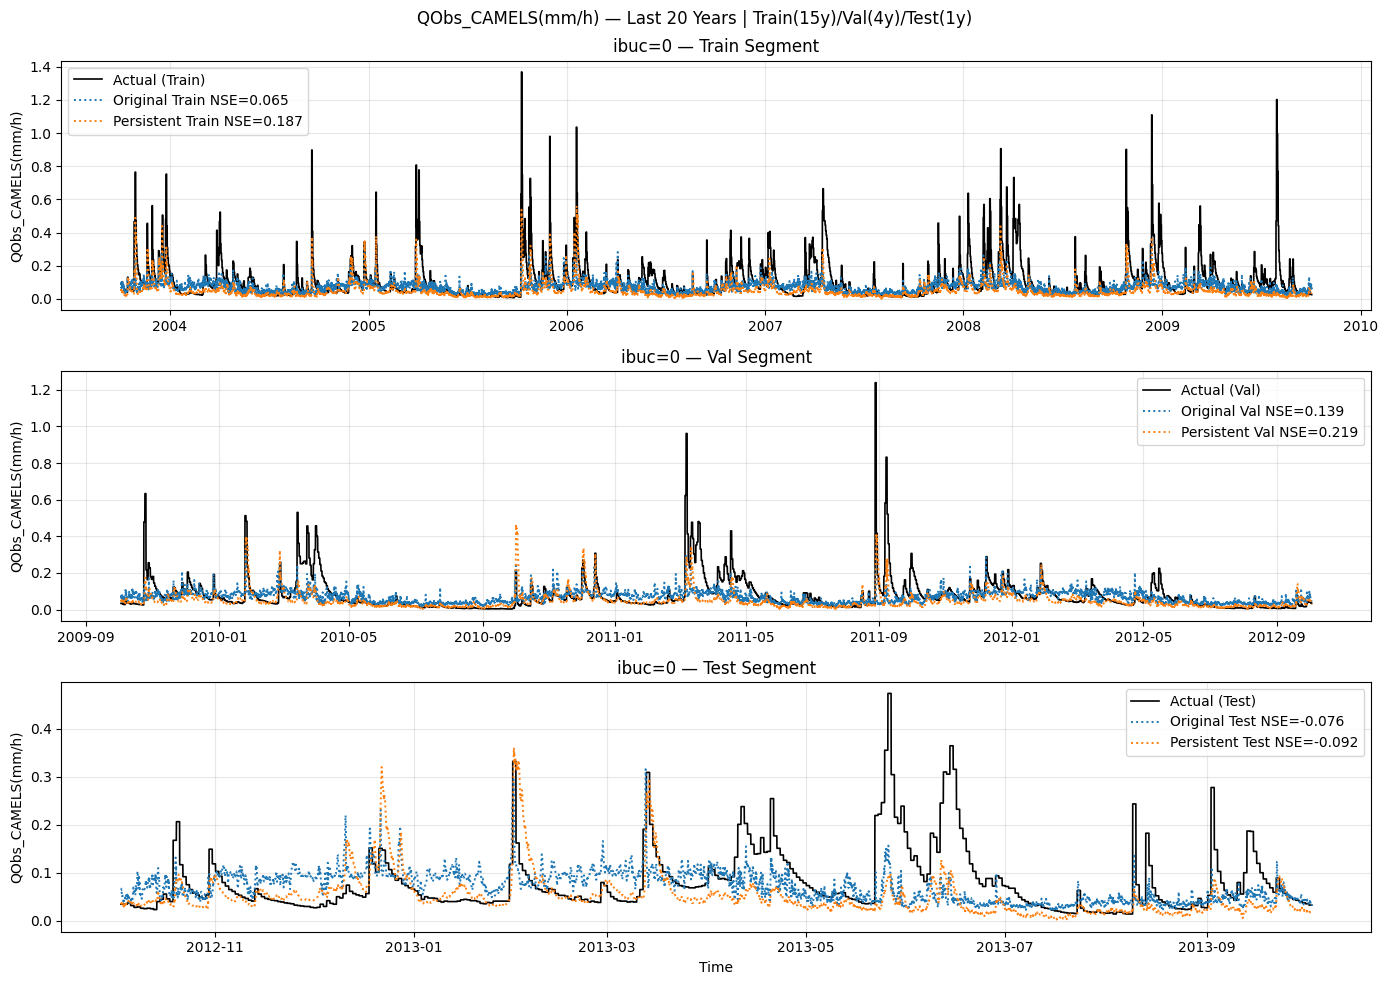

Plotting ibuc=1 …


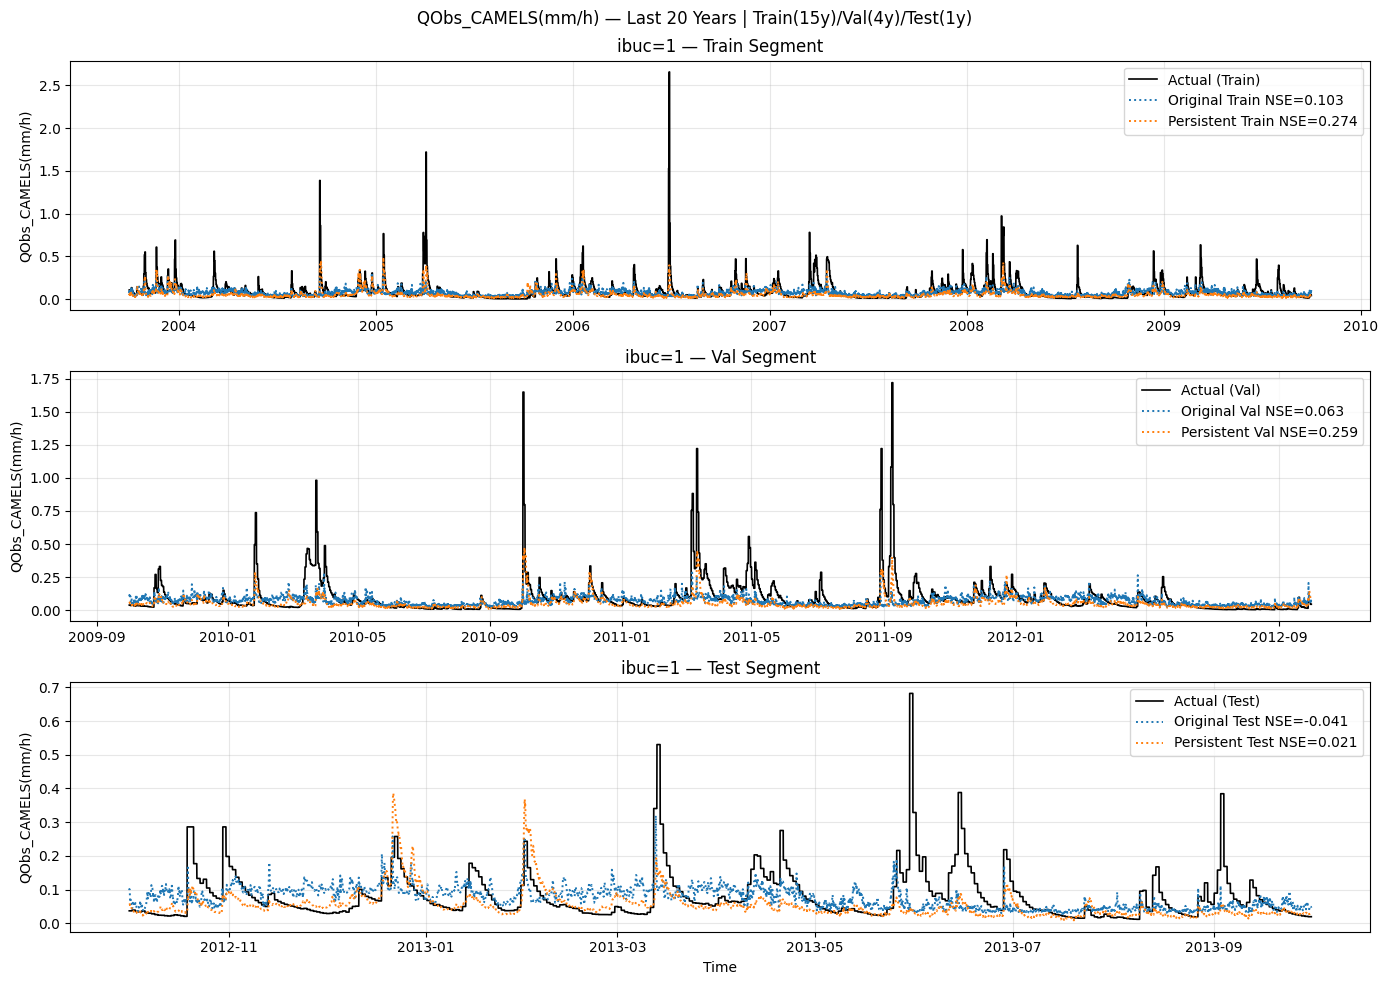

Plotting ibuc=2 …


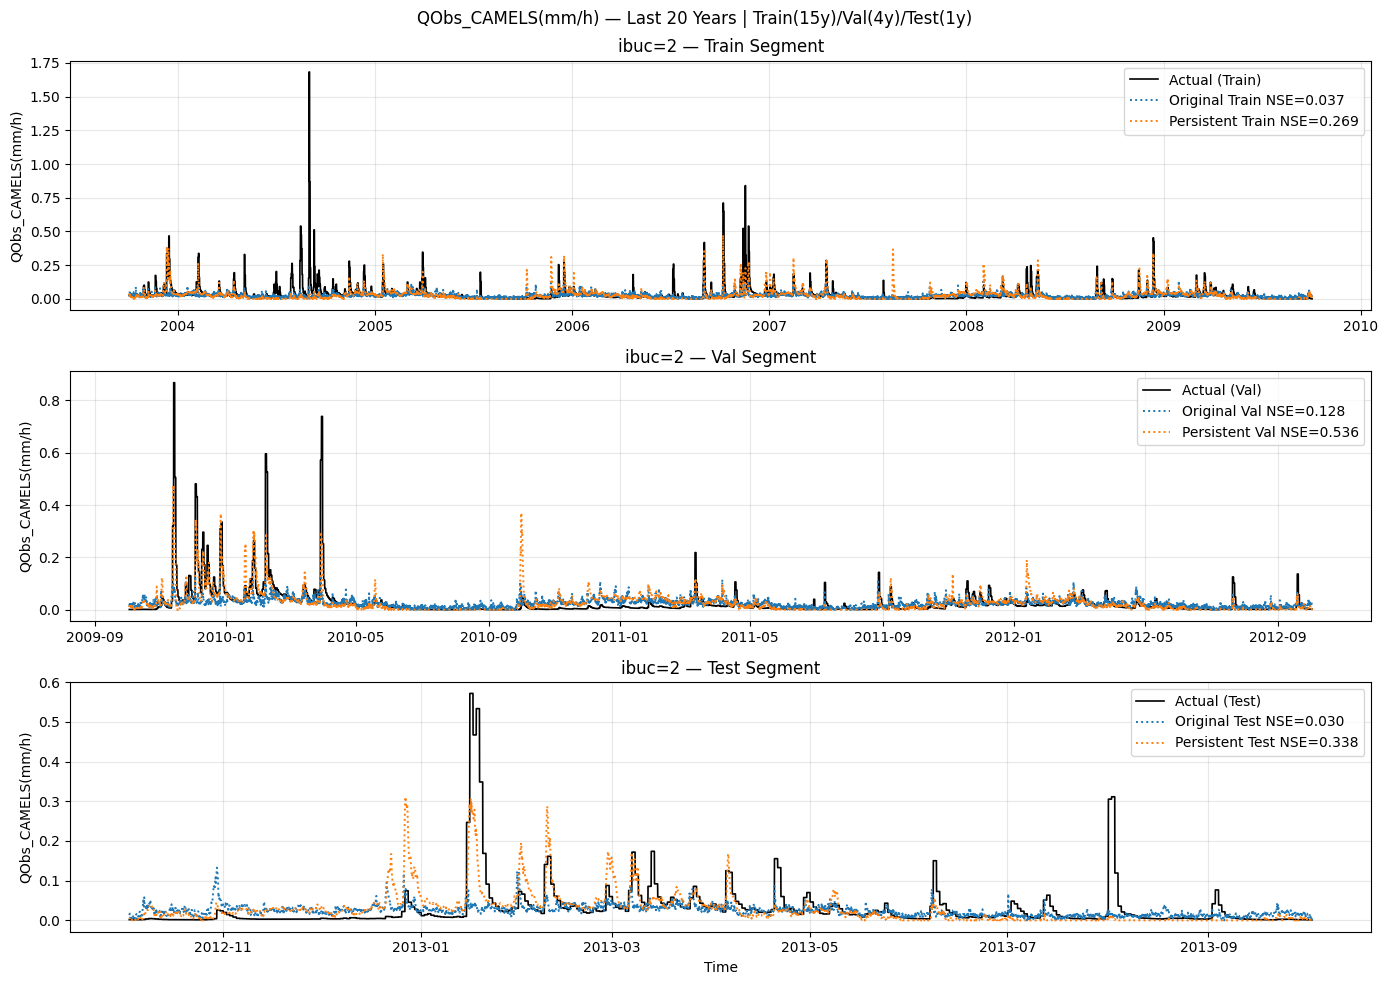

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader, Sampler
import gc

# ----------------------------
# Device
# ----------------------------
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Using CUDA:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon (Metal)")
else:
    device = torch.device("cpu")
    print("Using CPU")



# CAMELS NLDAS input feature columns (exclude 'date')
camels_input_cols = [
    "convective_fraction",
    "longwave_radiation",
    "potential_energy",
    "potential_evaporation",
    "pressure",
    "shortwave_radiation",
    "specific_humidity",
    "temperature",
    "total_precipitation",
    "wind_u",
    "wind_v",
]
# USGS/CAMELS target column
target_col = "QObs_CAMELS(mm/h)"

def load_camels_hourly(input_csv, output_csv):
    df_x = pd.read_csv(input_csv)
    df_y = pd.read_csv(output_csv)
    df_x["date"] = pd.to_datetime(df_x["date"])
    df_y["date"] = pd.to_datetime(df_y["date"])
    df_x = df_x[["date"] + camels_input_cols]
    df_y = df_y["date"].to_frame().join(df_y[target_col])
    df = (pd.merge(df_x, df_y, on="date", how="inner")
            .dropna(subset=camels_input_cols + [target_col])
            .sort_values("date")
            .reset_index(drop=True))
    df.index = np.arange(len(df))
    return df


BASINS = [
    dict(ibuc=0,
         X="../CAMELS_data_sample/hourly/nldas_hourly/01333000_hourly_nldas.csv",
         Y="../CAMELS_data_sample/hourly/usgs-streamflow/01333000-usgs-hourly.csv"),
    dict(ibuc=1,
         X="../CAMELS_data_sample/hourly/nldas_hourly/01423000_hourly_nldas.csv",
         Y="../CAMELS_data_sample/hourly/usgs-streamflow/01423000-usgs-hourly.csv"),
    dict(ibuc=2,
         X="../CAMELS_data_sample/hourly/nldas_hourly/02046000_hourly_nldas.csv",
         Y="../CAMELS_data_sample/hourly/usgs-streamflow/02046000-usgs-hourly.csv"),
]

bucket_dictionary = {}
for b in BASINS:
    bucket_dictionary[b["ibuc"]] = load_camels_hourly(b["X"], b["Y"])

# ----------------------------
# Globals / Params
# ----------------------------
input_vars  = camels_input_cols
output_vars = [target_col]
n_input  = len(input_vars)
n_output = len(output_vars)

hidden_state_size = 64
num_layers = 1
num_epochs = 18
batch_size_stateless = 64
seq_length = 5
batch_size_persistent = seq_length     # important for one-pred-per-time in persistent
learning_rate = np.array([1e-3]*6 + [5e-4]*6 + [1e-4]*6)
k_preds = 1
DROPOUT_P = 0.3                        # dropout probability (try 0.2–0.4)

# ============================================================
# USE ONLY LAST 20 YEARS, THEN 15y/4y/1y SPLIT (by timestamps)
# ============================================================
YEARS_BACK = 10
TRAIN_YEARS, VAL_YEARS, TEST_YEARS = 6, 3, 1

def restrict_to_last_years(df, years_back=5):
    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years_back)
    df2 = df[df["date"] >= start_date].copy().reset_index(drop=True)
    df2.index = np.arange(len(df2))
    if len(df2) < seq_length * 4:
        raise ValueError(f"Not enough rows after {years_back}y restriction: {len(df2)}")
    return df2

for ibuc in bucket_dictionary:
    bucket_dictionary[ibuc] = restrict_to_last_years(bucket_dictionary[ibuc], years_back=YEARS_BACK)

def compute_date_splits(df, train_years=15, val_years=4, test_years=1, seq_length=64):
    """Return inclusive index boundaries for train/val/test (df already last-N years)."""
    end_date = df["date"].max()
    test_start_date  = end_date - pd.DateOffset(years=test_years)
    val_start_date   = test_start_date - pd.DateOffset(years=val_years)
    train_start_date = val_start_date  - pd.DateOffset(years=train_years)
    train_start_date = max(train_start_date, df["date"].min())

    i_train_start = int(df["date"].searchsorted(train_start_date, side="left"))
    i_val_start   = int(df["date"].searchsorted(val_start_date,   side="left"))
    i_test_start  = int(df["date"].searchsorted(test_start_date,  side="left"))
    i_end         = len(df) - 1

    assert (i_val_start - i_train_start) >= seq_length, "Train slice too short for seq_length"
    assert (i_test_start - i_val_start)  >= seq_length, "Val slice too short for seq_length"
    assert (i_end + 1 - i_test_start)    >= seq_length, "Test slice too short for seq_length"

    return {
        "train": (i_train_start, i_val_start - 1),
        "val":   (i_val_start,   i_test_start - 1),
        "test":  (i_test_start,  i_end)
    }

# per-basin splits
date_splits = {}
for ibuc in bucket_dictionary:
    date_splits[ibuc] = compute_date_splits(bucket_dictionary[ibuc],
                                            train_years=TRAIN_YEARS,
                                            val_years=VAL_YEARS,
                                            test_years=TEST_YEARS,
                                            seq_length=seq_length)

buckets_for_training = list(bucket_dictionary.keys())
buckets_for_val      = list(bucket_dictionary.keys())
buckets_for_test     = list(bucket_dictionary.keys())

print("Basins:", buckets_for_training)
for ibuc in buckets_for_training:
    tr = date_splits[ibuc]["train"]; va = date_splits[ibuc]["val"]; te = date_splits[ibuc]["test"]
    print(f"ibuc={ibuc} Train[{tr[0]},{tr[1]}]  Val[{va[0]},{va[1]}]  Test[{te[0]},{te[1]}]")

# ============================================================
# MODELS (with dropout)
# ============================================================
class LSTMOriginal(nn.Module):
    """Stateless LSTM with dropout (internal + external)."""
    def __init__(self, num_classes, input_size, hidden_size, num_layers, dropout_p=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p
        )
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, init_states=None):
        if init_states is None:
            B = x.size(0)
            h0 = torch.zeros(self.lstm.num_layers, B, self.lstm.hidden_size, device=x.device)
            c0 = torch.zeros(self.lstm.num_layers, B, self.lstm.hidden_size, device=x.device)
            init_states = (h0, c0)
        out, _ = self.lstm(x, init_states)   # [B, T, H]
        out = self.dropout(out)              # external dropout
        pred = self.fc(out)                  # [B, T, C]
        return pred

class LSTMPersistent(nn.Module):
    """Stateful LSTM with dropout (internal + external)."""
    def __init__(self, num_classes, input_size, hidden_size, num_layers, dropout_p=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p
        )
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(hidden_size, num_classes)
        # This variable will store the *persistent hidden state* between batches
        self.hidden = None

    def forward(self, x, init_states=None):
        """
        Forward pass:
        - If a hidden state exists, reuse it (this is persistence).
        - Otherwise, initialize new hidden states.
        - After the LSTM forward pass, the new hidden state is saved in self.hidden.
        """
        if init_states is not None:
            # If given, start with provided initial states
            self.hidden = init_states
        # Pass previous hidden state (self.hidden) into LSTM
        #  This is where 'loading' of the previous state happens.
        out, self.hidden = self.lstm(x, self.hidden)
        out = self.dropout(out)
        pred = self.fc(out)
        return pred

    def init_hidden(self, batch_size=1, device='cpu'):
        """
        Initialize hidden and cell states (h0, c0) to zeros for a fresh start.
        This is used when no previous state exists.
        """
        H, L = self.lstm.hidden_size, self.lstm.num_layers
        self.hidden = (
            torch.zeros(L, batch_size, H, device=device),
            torch.zeros(L, batch_size, H, device=device),
        )

    def detach_hidden(self):
        """
        Detach hidden state from the computational graph.
        This *keeps* the numeric values (memory content) but stops backprop through time across batches.
        """
        if self.hidden is not None:
            self.hidden = (self.hidden[0].detach(), self.hidden[1].detach())

    def reset_hidden(self):
        """
        Reset the hidden state completely when switching to a new basin.
        """
        self.hidden = None

# ----------------------------
# Scalers (fit on TRAIN of all basins)
# ----------------------------
def fit_scaler_multi():
    frames_in, frames_out = [], []
    for ibuc in buckets_for_training:
        s,e = date_splits[ibuc]["train"]
        df = bucket_dictionary[ibuc]
        frames_in.append(df.loc[s:e, input_vars])
        frames_out.append(df.loc[s:e, output_vars])
    df_in  = pd.concat(frames_in,  axis=0)
    df_out = pd.concat(frames_out, axis=0)
    scaler_in  = StandardScaler().fit(df_in)
    scaler_out = StandardScaler().fit(df_out)
    return scaler_in, scaler_out

scaler_in, scaler_out = fit_scaler_multi()

def _denorm_from_scaler(x_std):
    # for output_vars[0]
    mu = float(scaler_out.mean_[0])
    sd = float(scaler_out.scale_[0])  # StandardScaler stores std in 'scale_'
    return max(x_std * sd + mu, 0.0)

# ============================================================
# Windowed datasets + loaders
# ============================================================
def make_window_arrays(df, start_idx, end_idx, seq_length):
    """Return X,Y arrays with stride=1 window starts (for maximum flexibility)."""
    end_idx = min(end_idx, len(df) - 1)
    start_idx = min(start_idx, end_idx)
    Xin = scaler_in.transform(df.loc[start_idx:end_idx, input_vars])
    Yin = scaler_out.transform(df.loc[start_idx:end_idx, output_vars])

    n_total = Xin.shape[0]
    if n_total < seq_length:
        raise ValueError(f"Slice too short: n_total={n_total}, seq_length={seq_length}")

    n_samples = n_total - seq_length + 1
    X = np.zeros((n_samples, seq_length, n_input), dtype=np.float32)
    Y = np.zeros((n_samples, seq_length, n_output), dtype=np.float32)
    for i in range(n_samples):
        t0 = i + seq_length
        X[i] = Xin[i:t0]
        Y[i] = Yin[i:t0]
    return X, Y

class SequentialBatchSampler(Sampler):
    """Sequential block sampler (stateless path)."""
    def __init__(self, n_samples: int, batch_size: int, seq_length: int):
        self.n_samples = n_samples
        self.batch_size = batch_size
        self.seq_length = seq_length
        self.num_batches = n_samples // batch_size

    def __iter__(self):
        for i in range(self.num_batches):
            start = i * self.batch_size
            yield list(range(start, start + self.batch_size))

    def __len__(self):
        return self.num_batches

class SlotPreservingChunkSampler(Sampler):
    """
    Batch 0: [0..L-1], [1..L], [2..L+1], ... this pattern is for persistent LSTM!!!
    Batch 1: [+L .. +2L-1], ...
    """
    def __init__(self, n_samples: int, batch_size: int, seq_length: int):
        assert n_samples >= batch_size, "Need at least batch_size samples"
        self.n = n_samples
        self.B = batch_size
        self.L = seq_length
        self.T = (n_samples - batch_size) // seq_length + 1  # include last valid step

    def __iter__(self):
        for t in range(self.T):
            base = t * self.L
            yield list(range(base, base + self.B))

    def __len__(self):
        return self.T

def make_stateless_loader(start, end, ibuc_list, batch_size):
    loader = {}
    arraysX, arraysY = {}, {}
    for ibuc in ibuc_list:
        df = bucket_dictionary[ibuc]
        X, Y = make_window_arrays(df, start, end, seq_length)
        arraysX[ibuc], arraysY[ibuc] = X, Y
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
        loader[ibuc] = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=True)
    return loader, arraysX, arraysY

def make_persistent_loader(start, end, ibuc_list, batch_size):
    loader = {}
    arraysX, arraysY = {}, {}
    for ibuc in ibuc_list:
        df = bucket_dictionary[ibuc]
        X, Y = make_window_arrays(df, start, end, seq_length)
        arraysX[ibuc], arraysY[ibuc] = X, Y
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
        #  here we are using SlotPreservingChunkSampler
        sampler = SlotPreservingChunkSampler(
            n_samples=X.shape[0], batch_size=batch_size, seq_length=seq_length
        )
        loader[ibuc] = DataLoader(ds, batch_sampler=sampler)
    return loader, arraysX, arraysY

def build_all_loaders():
    train_loader_std, val_loader_std, test_loader_std = {}, {}, {}
    train_loader_pers, val_loader_pers, test_loader_pers = {}, {}, {}
    np_train_seq_X, np_val_seq_X, np_test_seq_X = {}, {}, {}
    np_train_seq_y, np_val_seq_y, np_test_seq_y = {}, {}, {}

    for ibuc in bucket_dictionary:
        s_tr,e_tr = date_splits[ibuc]["train"]
        s_va,e_va = date_splits[ibuc]["val"]
        s_te,e_te = date_splits[ibuc]["test"]

        # stateless
        ld, X, Y = make_stateless_loader(s_tr, e_tr, [ibuc], batch_size_stateless)
        train_loader_std[ibuc] = ld[ibuc]; np_train_seq_X[ibuc]=X[ibuc]; np_train_seq_y[ibuc]=Y[ibuc]
        ld, X, Y = make_stateless_loader(s_va, e_va, [ibuc], batch_size_stateless)
        val_loader_std[ibuc]   = ld[ibuc]; np_val_seq_X[ibuc]=X[ibuc];   np_val_seq_y[ibuc]=Y[ibuc]
        ld, X, Y = make_stateless_loader(s_te, e_te, [ibuc], batch_size_stateless)
        test_loader_std[ibuc]  = ld[ibuc]; np_test_seq_X[ibuc]=X[ibuc];  np_test_seq_y[ibuc]=Y[ibuc]

        # persistent
        ld, _, _ = make_persistent_loader(s_tr, e_tr, [ibuc], batch_size_persistent)
        train_loader_pers[ibuc] = ld[ibuc]
        ld, _, _ = make_persistent_loader(s_va, e_va, [ibuc], batch_size_persistent)
        val_loader_pers[ibuc] = ld[ibuc]
        ld, _, _ = make_persistent_loader(s_te, e_te, [ibuc], batch_size_persistent)
        test_loader_pers[ibuc] = ld[ibuc]

    return (train_loader_std, val_loader_std, test_loader_std,
            train_loader_pers, val_loader_pers, test_loader_pers,
            np_train_seq_X, np_val_seq_X, np_test_seq_X,
            np_train_seq_y, np_val_seq_y, np_test_seq_y)

# Build loaders for all basins
(train_loader_std, val_loader_std, test_loader_std,
 train_loader_pers, val_loader_pers, test_loader_pers,
 np_train_seq_X, np_val_seq_X, np_test_seq_X,
 np_train_seq_y, np_val_seq_y, np_test_seq_y) = build_all_loaders()

# ============================================================
# Training
# ============================================================
def train_original_model(lstm, train_loader, buckets_for_training):
    lstm.train()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(lstm.parameters(), lr=float(learning_rate[0]), weight_decay=1e-5)
    results = {ibuc: {"loss": [], "RMSE": []} for ibuc in buckets_for_training}

    for epoch in range(num_epochs):
        for g in optimizer.param_groups:
            g['lr'] = float(learning_rate[epoch])

        epoch_losses = []
        for ibuc in buckets_for_training:
            for data, targets in train_loader[ibuc]:
                data, targets = data.to(device), targets.to(device)
                optimizer.zero_grad()
                out = lstm(data)
                preds = out[:, -k_preds:, :]
                true  = targets[:, -k_preds:, :]
                loss = criterion(preds, true)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(lstm.parameters(), 1.0)
                optimizer.step()
                epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses)) if epoch_losses else 0.0
        mean_rmse = float(np.sqrt(mean_loss))
        if epoch % 2 == 0:
            print(f"[Original] Epoch {epoch:02d} | lr={optimizer.param_groups[0]['lr']:.6f} | loss={mean_loss:.4f} | RMSE={mean_rmse:.4f}")

        for ibuc in buckets_for_training:
            results[ibuc]["loss"].append(mean_loss)
            results[ibuc]["RMSE"].append(mean_rmse)

    return lstm, results

def train_persistent_model(model, train_loader, buckets_for_training, batch_size):
    """
    Persistent training loop explanation:
    - Uses same hidden state across consecutive batches (memory persistence).
    - After each optimizer step, we detach the hidden state to stop gradient backflow.
    - When switching basins, we reset the hidden state.
    """

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=float(learning_rate[0]), weight_decay=1e-5)
    criterion_all = nn.MSELoss(reduction="mean")
    epoch_losses = []

    for epoch in range(num_epochs):
        for g in optimizer.param_groups:
            g['lr'] = float(learning_rate[epoch])

        losses = []
         # Loop through each basin or data stream
        for ibuc in buckets_for_training:
           # Start each basin with a fresh state (no leakage between basins)
            model.reset_hidden()
            # Loop through batches for this basin
            for data, targets in train_loader[ibuc]:
                data, targets = data.to(device), targets.to(device)

                if model.hidden is None:
                    model.init_hidden(batch_size=data.size(0), device=device)
 # Forward pass (loads previous hidden state automatically)
                optimizer.zero_grad()
                out = model(data)                 # [B, L, C],  Persistent state is passed implicitly here
                # Compute loss on all time steps
                loss = criterion_all(out, targets)
                loss.backward()
                # Clip gradients to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                  # Detach hidden state to prevent backprop through previous batches
                model.detach_hidden()
                losses.append(loss.item())
            torch.cuda.empty_cache()
            gc.collect()
  # Compute average loss for the epoch
        mean_loss = float(np.mean(losses)) if losses else 0.0
        mean_rmse = float(np.sqrt(mean_loss))
        if epoch % 2 == 0:
            print(f"[Persistent] Epoch {epoch:02d} | lr={optimizer.param_groups[0]['lr']:.6f} | loss={mean_loss:.4f} | RMSE={mean_rmse:.4f}")
        epoch_losses.append(mean_loss)

    results = {ibuc: {"loss": epoch_losses, "RMSE": [float(np.sqrt(l)) for l in epoch_losses]}
               for ibuc in buckets_for_training}
    return model, results

# ============================================================
# Evaluation helpers & plotting
# ============================================================
def compute_nse(pred, obs):
    pred = np.asarray(pred).ravel()
    obs  = np.asarray(obs).ravel()
    denom = np.sum((obs - np.mean(obs))**2)
    if denom == 0:
        return -999.0
    return 1.0 - np.sum((obs - pred)**2) / denom

def predict_block_original(lstm_original, np_seq_X_dict, ibuc, batch_size_eval=256):
    """Stateless predictions (dense). Returns list of denormalized last-step per window."""
    lstm_original.eval()
    X_all = np_seq_X_dict[ibuc]                 # NumPy array [N, L, F]
    N = X_all.shape[0]
    preds = []

    with torch.no_grad():
        for i in range(0, N, batch_size_eval):
            X_batch_np = X_all[i:i+batch_size_eval]                         # (B, L, F)
            X_batch = torch.tensor(X_batch_np, dtype=torch.float32, device=device)
            out = lstm_original(X_batch)                                    # [B, L, C]
            last = out[:, -1, :].cpu().numpy()                              # (B, C) numpy
            # append each row (one per sample) to preds
            for row in last:
                preds.append(float(row[0]))                                 # raw (standardized) scalar
            # cleanup
            del X_batch, out, last
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    # Denormalize all predicted standardized scalars
    preds_denorm = [_denorm_from_scaler(p) for p in preds]
    return preds_denorm


def predict_block_persistent(lstm_persistent, np_seq_X_dict, ibuc, batch_size, base_idx, df):
    """
    Stateful predictions (slot-preserving, step=L). Returns (obs_indices, preds).
    obs_indices are absolute df indices: base_idx + start + (seq_length - 1)
    """
    lstm_persistent.eval()
    Xfull = torch.tensor(np_seq_X_dict[ibuc], dtype=torch.float32, device=device)  # [N, L, F]
    preds_idx, preds_val = [], []

    sampler = SlotPreservingChunkSampler(
        n_samples=Xfull.size(0),
        batch_size=batch_size,
        seq_length=seq_length
    )
    lstm_persistent.reset_hidden()
    with torch.no_grad():
        for idx_batch in sampler:
            x = Xfull[idx_batch]
            if lstm_persistent.hidden is None:
                lstm_persistent.init_hidden(batch_size=x.size(0), device=device)
            out = lstm_persistent(x)   # [B, L, C]
            last = out[:, -1, :]       # [B, C]
            for b, start_idx in enumerate(idx_batch):
                obs_index = int(base_idx) + int(start_idx) + (seq_length - 1)
                preds_idx.append(obs_index)
                preds_val.append(_denorm_from_scaler(float(last[b, 0].cpu().numpy())))
            lstm_persistent.detach_hidden()
    return preds_idx, preds_val

def obs_dense_for(df, start_idx, end_idx, n_preds, var):
    t0 = start_idx + (seq_length - 1)
    t1 = min(t0 + n_preds - 1, end_idx)
    obs = df.loc[t0:t1, var].values
    dates = df.loc[t0:t1, "date"].values
    return obs, dates

def nse_sparse(idx_list, preds_list, df, s, e, var):
    keep = [i for i in idx_list if (s + (seq_length - 1)) <= i <= e]
    if not keep:
        return np.nan
    m = {i: v for i, v in zip(idx_list, preds_list)}
    obs = [df.loc[i, var] for i in sorted(set(keep))]
    prd = [m[i] for i in sorted(set(keep))]
    return compute_nse(prd, obs)

def eval_all_basins(lstm_o, lstm_p):
    per_basin = {}
    for ibuc in bucket_dictionary:
        df = bucket_dictionary[ibuc]
        s_tr,e_tr = date_splits[ibuc]["train"]
        s_va,e_va = date_splits[ibuc]["val"]
        s_te,e_te = date_splits[ibuc]["test"]

        # Original (dense)
        o_tr = predict_block_original(lstm_o, np_train_seq_X, ibuc)
        o_va = predict_block_original(lstm_o, np_val_seq_X,   ibuc)
        o_te = predict_block_original(lstm_o, np_test_seq_X,  ibuc)
        obs_tr,_ = obs_dense_for(df, s_tr, e_tr, len(o_tr), output_vars[0])
        obs_va,_ = obs_dense_for(df, s_va, e_va, len(o_va), output_vars[0])
        obs_te,_ = obs_dense_for(df, s_te, e_te, len(o_te), output_vars[0])
        nse_o_tr = compute_nse(o_tr[:len(obs_tr)], obs_tr)
        nse_o_va = compute_nse(o_va[:len(obs_va)], obs_va)
        nse_o_te = compute_nse(o_te[:len(obs_te)], obs_te)

        # Persistent (sparse last-only)
        idx_tr, p_tr = predict_block_persistent(lstm_p, np_train_seq_X, ibuc, batch_size_persistent, base_idx=s_tr, df=df)
        idx_va, p_va = predict_block_persistent(lstm_p, np_val_seq_X,   ibuc, batch_size_persistent, base_idx=s_va, df=df)
        idx_te, p_te = predict_block_persistent(lstm_p, np_test_seq_X,  ibuc, batch_size_persistent, base_idx=s_te, df=df)
        nse_p_tr = nse_sparse(idx_tr, p_tr, df, s_tr, e_tr, output_vars[0])
        nse_p_va = nse_sparse(idx_va, p_va, df, s_va, e_va, output_vars[0])
        nse_p_te = nse_sparse(idx_te, p_te, df, s_te, e_te, output_vars[0])

        per_basin[ibuc] = dict(orig=(nse_o_tr, nse_o_va, nse_o_te),
                               pers=(nse_p_tr, nse_p_va, nse_p_te))

    arr_o = np.array([per_basin[i]["orig"] for i in per_basin], dtype=float)
    arr_p = np.array([per_basin[i]["pers"] for i in per_basin], dtype=float)
    avg_orig = np.nanmean(arr_o, axis=0)  # (train,val,test)
    avg_pers = np.nanmean(arr_p, axis=0)
    return per_basin, avg_orig, avg_pers

def plot_train_val_test_subplots_for(ibuc, lstm_original, lstm_persistent, var=target_col):
    """Plot for a single basin id (default ibuc=0)."""
    df = bucket_dictionary[ibuc]
    s_tr,e_tr = date_splits[ibuc]["train"]
    s_va,e_va = date_splits[ibuc]["val"]
    s_te,e_te = date_splits[ibuc]["test"]

    # Dense (original) predictions
    orig_train = predict_block_original(lstm_original, np_train_seq_X, ibuc)
    orig_val   = predict_block_original(lstm_original, np_val_seq_X,   ibuc)
    orig_test  = predict_block_original(lstm_original, np_test_seq_X,  ibuc)

    # Persistent predictions with absolute indices (slot-preserving, step=L)
    idx_p_tr, pers_train = predict_block_persistent(lstm_persistent, np_train_seq_X, ibuc, batch_size_persistent, base_idx=s_tr, df=df)
    idx_p_va, pers_val   = predict_block_persistent(lstm_persistent, np_val_seq_X,   ibuc, batch_size_persistent, base_idx=s_va, df=df)
    idx_p_te, pers_test  = predict_block_persistent(lstm_persistent, np_test_seq_X,  ibuc, batch_size_persistent, base_idx=s_te, df=df)

    # Helper: observations aligned to dense (original) coverage
    def obs_dense(start_idx, end_idx, n_preds):
        t0 = start_idx + (seq_length - 1)
        t1 = min(t0 + n_preds - 1, end_idx)
        obs = df.loc[t0:t1, var].values
        dates = df.loc[t0:t1, "date"].values
        return obs, dates, t0, t1

    obs_tr, dates_tr, _, _ = obs_dense(s_tr, e_tr, len(orig_train))
    obs_va, dates_va, _, _ = obs_dense(s_va, e_va, len(orig_val))
    obs_te, dates_te, _, _ = obs_dense(s_te, e_te, len(orig_test))

    # NSE values
    NSE = lambda p, o: compute_nse(p[:len(o)], o)
    nse_o_tr, nse_o_va, nse_o_te = NSE(orig_train, obs_tr), NSE(orig_val, obs_va), NSE(orig_test, obs_te)

    def nse_sparse_local(idx_list, preds_list, start_idx, end_idx):
        keep = [i for i in idx_list if (start_idx + (seq_length - 1)) <= i <= end_idx]
        if not keep:
            return np.nan
        m = {i: v for i, v in zip(idx_list, preds_list)}
        obs = [df.loc[i, var] for i in sorted(set(keep))]
        prd = [m[i]           for i in sorted(set(keep))]
        return compute_nse(prd, obs)

    nse_p_tr = nse_sparse_local(idx_p_tr, pers_train, s_tr, e_tr)
    nse_p_va = nse_sparse_local(idx_p_va, pers_val,   s_va, e_va)
    nse_p_te = nse_sparse_local(idx_p_te, pers_test,  s_te, e_te)

    # --- 3 subplots (dotted predictions) ---
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
    panels = [
        ("Train", dates_tr, obs_tr, orig_train, (pd.to_datetime(df.loc[idx_p_tr, "date"]).values, pers_train), nse_o_tr, nse_p_tr),
        ("Val",   dates_va, obs_va, orig_val,   (pd.to_datetime(df.loc[idx_p_va, "date"]).values, pers_val),   nse_o_va, nse_p_va),
        ("Test",  dates_te, obs_te, orig_test,  (pd.to_datetime(df.loc[idx_p_te, "date"]).values, pers_test),  nse_o_te, nse_p_te),
    ]
    for ax, (name, dates, obs, orig_pred, (p_dates, p_pred), nse_o, nse_p) in zip(axes, panels):
        ax.plot(dates, obs, '-', linewidth=1.2, color='k', label=f'Actual ({name})')
        ax.plot(dates, orig_pred[:len(dates)], ':', linewidth=1.4, label=f'Original {name} NSE={nse_o:.3f}')
        ax.plot(p_dates, p_pred, ':', linewidth=1.4, label=f'Persistent {name} NSE={np.nan if nse_p is None else nse_p:.3f}')
        ax.set_ylabel(var)
        ax.set_title(f'ibuc={ibuc} — {name} Segment')
        ax.grid(True, alpha=0.3)
        ax.legend()
    axes[-1].set_xlabel('Time')
    fig.suptitle(f'{var} — Last 20 Years | Train(15y)/Val(4y)/Test(1y)', y=0.98)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Main execution
# ----------------------------
torch.manual_seed(1)

lstm_persistent = LSTMPersistent(
    num_classes=n_output,
    input_size=n_input,
    hidden_size=hidden_state_size,
    num_layers=num_layers,
    dropout_p=DROPOUT_P
).to(device)

lstm_original = LSTMOriginal(
    num_classes=n_output,
    input_size=n_input,
    hidden_size=hidden_state_size,
    num_layers=num_layers,
    dropout_p=DROPOUT_P
).to(device)


print("\n" + "="*60)
print("TRAINING PERSISTENT (STATEFUL) LSTM — slot-preserving, step=L, all-steps loss")
print("="*60)
lstm_persistent, _ = train_persistent_model(
    lstm_persistent, train_loader_pers, buckets_for_training, batch_size_persistent
)

print("\n" + "="*60)
print("TRAINING ORIGINAL (STATELESS) LSTM")
print("="*60)
lstm_original, _ = train_original_model(lstm_original, train_loader_std, buckets_for_training)


# -------- EVALUATION: per-basin + macro-average --------
per_basin, avg_orig, avg_pers = eval_all_basins(lstm_original, lstm_persistent)
print("\nPer-basin NSE (train, val, test):")
for i in sorted(per_basin):
    print(f"ibuc {i}: Original {per_basin[i]['orig']},  Persistent {per_basin[i]['pers']}")
print("\nMacro-average NSE (Original)  Train/Val/Test:", avg_orig)
print("Macro-average NSE (Persistent) Train/Val/Test:", avg_pers)

# -------- PLOT: choose a basin to visualize (default 0) --------
print("\nPlotting all basins …")

for ibuc in bucket_dictionary.keys():
    print(f"Plotting ibuc={ibuc} …")
    plot_train_val_test_subplots_for(
        ibuc=ibuc,
        lstm_original=lstm_original,
        lstm_persistent=lstm_persistent,
        var=output_vars[0]
    )

